In [1]:
import numpy as np
import umap
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Load reduced data if starting fresh
X_reduced = np.load("X_reduced.npy")  # (n_pixels, 100)

### Tissue vs Background

In [26]:
from imzy import get_reader
from pathlib import Path

four_week_path = r"Y:\spraggins\sandbox\spathij\spinal cord injury round 1\spinal cord injury 3\4week_3.9_neg\4week_3.9_neg.d"
path = Path(four_week_path)
reader = get_reader(path)
tic = reader.get_tic()

In [36]:
# Simple threshold — pixels with too few nonzero bins are background
tissue_mask = tic > 100000  # tune this threshold
X_tissue = X_scaled[tissue_mask]
print("Tissue pixels: " + str(len(X_tissue)))

Tissue pixels: 109449


In [ ]:
# 100-200 whack values not screwing up everything.

### Take out first n-components

In [39]:
# Try skipping first 1, 2, 3, 5 components and see which gives best ARI
for skip in [0, 1, 2, 3, 5, 10]:
    X_test = StandardScaler().fit_transform(X_reduced[:, skip:])
    labels_test = MiniBatchKMeans(n_clusters=k, random_state=42).fit_predict(X_test)
    # Compare stability
    labels_test2 = MiniBatchKMeans(n_clusters=k, random_state=99).fit_predict(X_test)
    ari = adjusted_rand_score(labels_test, labels_test2)
    print(f"Skip {skip} components | ARI: {ari:.3f}")

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Skip 0 components | ARI: 0.168


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Skip 1 components | ARI: 0.069


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


...

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Skip 3 components | ARI: 0.005


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Skip 5 components | ARI: 0.050
Skip 10 components | ARI: 0.049


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


### Variance Explained

In [41]:
S = np.load("S.npy")  # (n_pixels, 100)

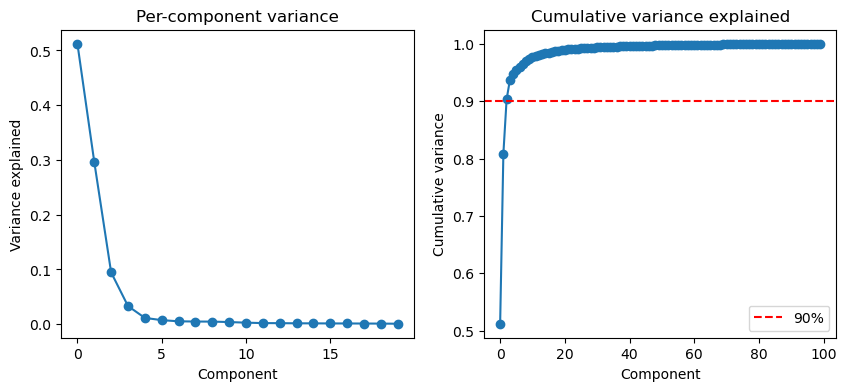

Component 0 explains: 51.2%
Components 0-4 explain: 94.8%


In [42]:
explained = (S**2) / (S**2).sum()
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(explained[:20], 'o-')
plt.xlabel("Component")
plt.ylabel("Variance explained")
plt.title("Per-component variance")

plt.subplot(1, 2, 2)
plt.plot(cumulative, 'o-')
plt.axhline(0.9, color='r', linestyle='--', label='90%')
plt.xlabel("Component")
plt.ylabel("Cumulative variance")
plt.title("Cumulative variance explained")
plt.legend()
plt.show()

# If the first component explains >50%, your data is dominated by one axis
print(f"Component 0 explains: {explained[0]:.1%}")
print(f"Components 0-4 explain: {cumulative[4]:.1%}")

### Leaving out the last n components

In [43]:
from sklearn.metrics import adjusted_rand_score

for n_comp in [10, 20, 30, 50, 75, 100]:
    X_test = StandardScaler().fit_transform(X_reduced[:, :n_comp])
    l1 = MiniBatchKMeans(n_clusters=k, random_state=42).fit_predict(X_test)
    l2 = MiniBatchKMeans(n_clusters=k, random_state=99).fit_predict(X_test)
    ari = adjusted_rand_score(l1, l2)
    print(f"n_components={n_comp:3d} | ARI: {ari:.3f}")

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

n_components= 10 | ARI: 0.713
n_components= 20 | ARI: 0.367


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

n_components= 30 | ARI: 0.150
n_components= 50 | ARI: 0.239


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

n_components= 75 | ARI: 0.191
n_components=100 | ARI: 0.168


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Wow! Clearly our last 90 components aren't doing much. Let's run this again for different values.

In [44]:
for n_comp in range(2, 16):
    X_test = StandardScaler().fit_transform(X_reduced[:, :n_comp])
    l1 = MiniBatchKMeans(n_clusters=k, random_state=42).fit_predict(X_test)
    l2 = MiniBatchKMeans(n_clusters=k, random_state=99).fit_predict(X_test)
    ari = adjusted_rand_score(l1, l2)
    print(f"n_components={n_comp:3d} | ARI: {ari:.3f}")

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


n_components=  2 | ARI: 0.557


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


n_components=  3 | ARI: 0.654


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

...

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


n_components= 13 | ARI: 0.531


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


n_components= 14 | ARI: 0.324
n_components= 15 | ARI: 0.316


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


In [63]:
useful_components = [0, 1, 2, 3]
X_test = StandardScaler().fit_transform(X_reduced[:, useful_components])
l1 = MiniBatchKMeans(n_clusters=k, random_state=42).fit_predict(X_test)
l2 = MiniBatchKMeans(n_clusters=k, random_state=99).fit_predict(X_test)
ari = adjusted_rand_score(l1, l2)
print(f"n_components=5 | ARI: {ari:.3f}")

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


n_components=5 | ARI: 0.820


In [56]:
X_reduced[:, useful_components].shape

(109663, 5)

In [45]:
# ── 1. Scale ──────────────────────────────────────────────────────────────────
# SVD components have different variances — scaling puts them on equal footing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced[:, :4])

In [46]:
# ── 2. UMAP ───────────────────────────────────────────────────────────────────
reducer = umap.UMAP(
    n_components=2,       # 2D embedding for visualization
    n_neighbors=30,       # Higher = more global structure preserved
    min_dist=0.5,         # Higher = more spread out clusters
    metric='euclidean',
    n_jobs=-1,
    random_state=42,
    verbose=True
)
embedding = reducer.fit_transform(X_scaled)  # (n_pixels, 2)
np.save("umap_embedding.npy", embedding)

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(min_dist=0.5, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Apr 21 09:34:24 2026 Construct fuzzy simplicial set
Tue Apr 21 09:34:24 2026 Finding Nearest Neighbors
Tue Apr 21 09:34:24 2026 Building RP forest with 22 trees
Tue Apr 21 09:34:24 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Tue Apr 21 09:34:31 2026 Finished Nearest Neighbor Search
Tue Apr 21 09:34:32 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Apr 21 09:36:42 2026 Finished embedding


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


k=2 done

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


k=3 done

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


...

k=21 done

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


k=23 done

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


k=24 done

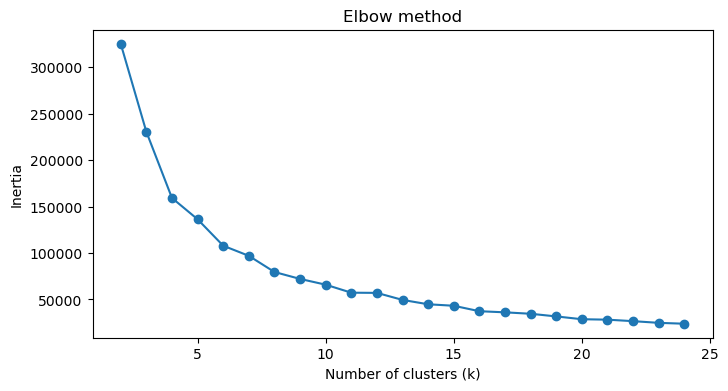

In [47]:
# ── 3. K-Means ────────────────────────────────────────────────────────────────
# Run on SVD-reduced data, not UMAP — UMAP distorts distances
# Use elbow method to pick k first

inertias = []
k_range = range(2, 25)
for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, init= 'k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"k={k} done", end='\r')

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'o-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

In [48]:
k = 12  # replace with your chosen k
km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)  # (n_pixels,) cluster label per pixel
np.save("cluster_labels.npy", labels)

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


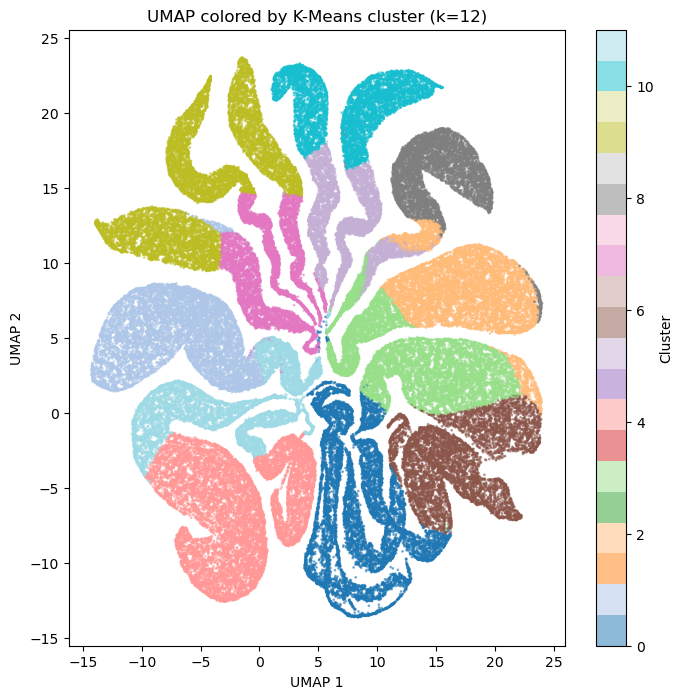

In [49]:
# ── 4. Visualize clusters on UMAP embedding ───────────────────────────────────
plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=labels, cmap='tab20',
    s=1, alpha=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.title(f"UMAP colored by K-Means cluster (k={k})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [22]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from scipy.sparse import lil_matrix, csr_matrix
from sklearn.metrics import adjusted_rand_score

k         = 8
n_runs    = 20
n_pixels  = X_scaled.shape[0]

# ── 1. Collect labels from multiple runs ──────────────────────────────────────
all_labels = np.zeros((n_runs, n_pixels), dtype=np.int32)

for i in range(n_runs):
    km = MiniBatchKMeans(
        n_clusters=k,
        n_init=5,
        random_state=i,  # different seed each run
    )
    all_labels[i] = km.fit_predict(X_scaled)
    print(f"Run {i+1}/{n_runs} | inertia: {km.inertia_:.2f}", end='\r')

np.save("all_labels.npy", all_labels)
print("\nAll runs complete")

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

Run 6/20 | inertia: 10101345.00

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

Run 10/20 | inertia: 10018254.00

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


...

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

Run 18/20 | inertia: 10041579.00

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Run 20/20 | inertia: 10015255.00
All runs complete


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


In [23]:
# ── Lighter alternative — just measure run stability ─────────────────────────
from sklearn.metrics import adjusted_rand_score
from itertools import combinations

scores = []
for i, j in combinations(range(n_runs), 2):
    scores.append(adjusted_rand_score(all_labels[i], all_labels[j]))

scores = np.array(scores)
print(f"Mean ARI across runs: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Min ARI: {scores.min():.3f}")
print(f"Max ARI: {scores.max():.3f}")

# ARI interpretation:
# > 0.9  — very stable, results are reliable
# 0.7-0.9 — reasonably stable
# < 0.7  — unstable, k may be wrong or data doesn't cluster well

Mean ARI across runs: 0.041 ± 0.029
Min ARI: -0.010
Max ARI: 0.116


In [24]:
# Pick best single run by inertia
inertias = []
for i in range(n_runs):
    km = MiniBatchKMeans(n_clusters=k, n_init=5, random_state=i)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

best_run = np.argmin(inertias)
best_labels = all_labels[best_run]
print(f"Best run: {best_run} with inertia {inertias[best_run]:.2f}")

C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  w

Best run: 2 with inertia 9981238.00


C:\Users\WS2\.conda\envs\Simeon\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
